#### The notebook contains tests on the library operating time for CW and time-resolved spectra

In [265]:
%load_ext autoreload
%autoreload 2

import sys
import os
import random
import typing as tp
import math
from importlib import reload
import functools
import pathlib

import csv
import json

import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))


import time
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Union, Tuple, List
from mars import spin_model, spectra_manager, mesher, constants
import mars

from sample_creators_local import (create_electron_nucleus, create_electron_anisotropic_chain,
                                   create_electron_DE_chain, create_electron_batch_size,
                                   create_relaxation_batch_size, create_relaxation_coupled
                                  )
from sample_relaxation_initial import (set_relaxation_and_initial_channels, set_relaxation_and_initial_channels_batches)

from saving_benchmarks import save_benchmark_results, load_benchmark_results
from bencmarking import (
    benchmark_several_configurations, compare_benchmarks, plot_benchmark_comparison,
    time_spectrum_calculation_full_pipeline, time_spectrum_calculation_full_pipeline_freqdep, time_spectrum_calculation_full_pipeline_timedep)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [266]:
random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

In [267]:
def save_csv(path: tp.Union[str, pathlib.Path], out_dict: tp.Dict[str, float], meta=tp.Dict[str, str]):
    with open(path, "w", newline="") as f:
        f.write(f'# {json.dumps(meta)}\n')

        fieldnames = out_dict[0].keys()
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(out_dict)

In [268]:
import matplotlib.pyplot as plt
dtype = torch.float64
device = torch.device("cpu")

mesh = mars.mesher.DelaunayMesh(initial_grid_frequency=25, interpolation_grid_frequency=20, interpolator="barycentric", dtype=dtype, interpolate=False)

In [269]:
freq = torch.tensor(9.8 * 1e9, dtype=dtype, device=device)
temperature = torch.tensor(300.0, dtype=dtype, device=device)
n_field_points = 1000

### 1. S = 1/2 electron spin connected with nuclei spins

In [172]:
sample_1 = create_electron_nucleus(mesh=mesh, num_nuclei=2, device=device, dtype=dtype)

field_range = (0.33, 0.37)
n_field_points = 1000

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_field_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_1,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_1, fields=fields)

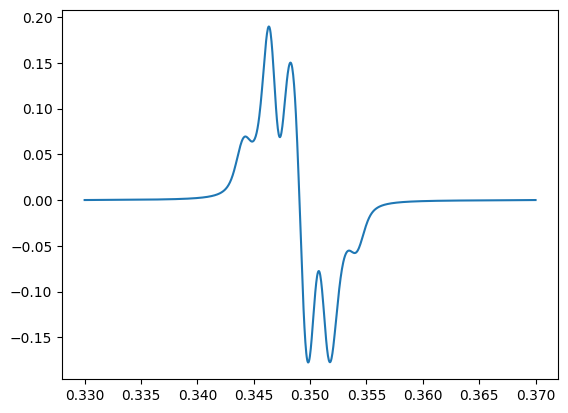

In [173]:
plt.plot(fields, out)

In [174]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)
time_calculation_results = []

path = f"example_1_{device}_dtype_{dtype}.csv"
meta = {"dtype": str(dtype), "device": str(device), "sample_description": "spin S = 1/2 connected with nuclei spins"}

for num_nuclei in range(2):
    sample_function = functools.partial(create_electron_nucleus, num_nuclei=num_nuclei)
    
    result = time_spectrum_calculation_full_pipeline(
        sample_creation_func=sample_function,
        sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
        freq=freq, field_range=field_range, n_points=n_field_points, temperature=temperature,
        computational_details=computational_details,
        n_warmup=2, n_iterations=5,
    )
    time_calculation_results.append({"num_nuclei": num_nuclei, "mean": result[0], "std": result[1]})
    save_csv(path, time_calculation_results, meta)

In [175]:
time_calculation_results

[{'num_nuclei': 0, 'mean': 35.71022000105586, 'std': 20.46562196667627},
 {'num_nuclei': 1, 'mean': 72.72131999779958, 'std': 19.286542815323653}]

### 2. S = 1/2 electron spin connected with one nuceli spin. Comparison the speed over batch size

In [107]:
batch_size=2
sample_2 = create_electron_batch_size(mesh=mesh, batch_size=batch_size, device=device, dtype=dtype)

field_range = (0.33, 0.37)

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_field_points,
            device=device,
            dtype=dtype
        ).expand(batch_size, -1)

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_2,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_2, fields=fields)

torch.Size([2, 1000])


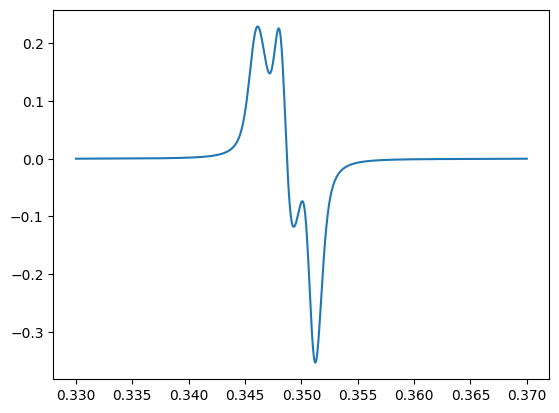

In [108]:
plt.plot(fields[1], out[1])

In [158]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)
time_calculation_results = []

path = f"example_2_{device}_dtype_{dtype}.csv"
meta = {"dtype": str(dtype), "device": str(device), "sample_description": "spin S = 1/2 connected with one nuclei spin in batch computations"}

for batch_size in range(1, 10):
    sample_function = functools.partial(create_electron_batch_size, batch_size=batch_size)

    result = time_spectrum_calculation_full_pipeline(
        sample_creation_func=sample_function,
        sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
        freq=freq, field_range=field_range, n_points=n_field_points, temperature=temperature,
        computational_details=computational_details,
        n_warmup=2, n_iterations=5,
    )
    time_calculation_results.append({"batch_size": batch_size, "mean": result[0] / batch_size, "std": result[1] / math.sqrt(batch_size)})
    
    save_csv(path, time_calculation_results, meta)

### 3. The chain of electrons S=1/2 connected to each other by exhcange interaction

In [213]:
sample_3 = create_electron_anisotropic_chain(mesh=mesh, num_electrons=1, device=device, dtype=dtype)

field_range = (0.27, 0.38)
n_field_points = 1000

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_field_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_3,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_3, fields=fields)

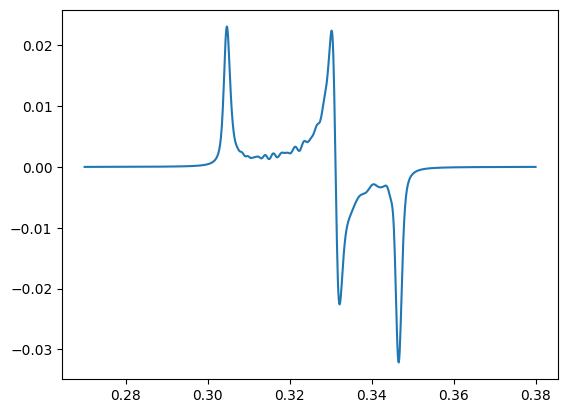

In [214]:
plt.plot(fields, out)

In [219]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)
time_calculation_results = []

path = f"example_3_{device}_dtype_{dtype}.csv"
meta = {"dtype": str(dtype), "device": str(device), "sample_description": "spin S = 1/2 connected with other spin 1/2 in chain"}

for num_electrons in range(1, 3):
    sample_function = functools.partial(create_electron_anisotropic_chain, num_electrons=num_electrons)

    result = time_spectrum_calculation_full_pipeline(
        sample_creation_func=sample_function,
        sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
        freq=freq, field_range=field_range, n_points=n_field_points, temperature=temperature,
        computational_details=computational_details,
        n_warmup=2, n_iterations=5,
    )
    time_calculation_results.append({"num_electrons": num_electrons, "mean": result[0], "std": result[1]})
    save_csv(path, time_calculation_results, meta)

In [220]:
time_calculation_results

[{'num_electrons': 1, 'mean': 20.150579998880858, 'std': 1.0401463880101967},
 {'num_electrons': 2, 'mean': 32.709080000495305, 'std': 1.0010896212389189}]

### 4. The chain of electrons S=1/2 connected to each other by dipolar interaction

In [241]:
sample_4 = create_electron_DE_chain(mesh=mesh, num_electrons=2, device=device, dtype=dtype)

field_range = (0.33, 0.37)
n_field_points = 1000

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_field_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)

creator = spectra_manager.StationarySpectra(
    freq=freq,
    sample=sample_4,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_4, fields=fields)

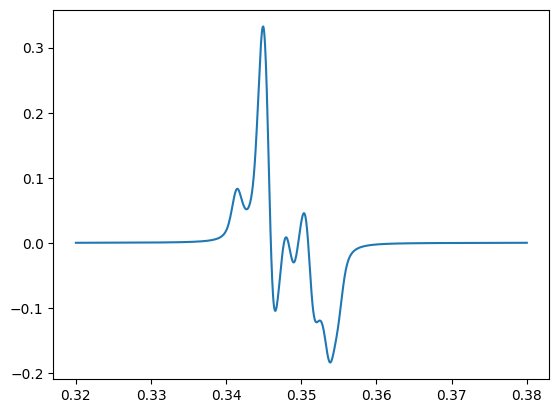

In [242]:
plt.plot(fields, out)

In [243]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)
time_calculation_results = []

path = f"example_4_{device}_dtype_{dtype}.csv"
meta = {"dtype": str(dtype), "device": str(device), "sample_description": "spin S = 1/2 connected with other spin 1/2 in chain with DE interaction"}

for num_electrons in range(1, 3):
    sample_function = functools.partial(create_electron_DE_chain, num_electrons=num_electrons)

    result = time_spectrum_cailculation_full_pipeline(
        sample_creation_func=sample_function,
        sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype},
        freq=freq, field_range=field_range, n_points=n_field_points, temperature=temperature,
        computational_details=computational_details,
        n_warmup=2, n_iterations=5,
    )
    time_calculation_results.append({"num_electrons": num_electrons, "mean": result[0], "std": result[1]})
    save_csv(path, time_calculation_results, meta)

### Time Resolved EPR Time comparison

### 5. System of S=1 + S = 1/2. Coupled by exchange interaction

In [250]:
sample_5 = create_relaxation_coupled(mesh=mesh, num_electrons=1, device=device, dtype=dtype)
context = set_relaxation_and_initial_channels(sample_5, num_contexts=3)


field_range = (0.27, 0.38)
time_points = 100
time_range = (0.0, 1.0 * 1e-4)
time_simulations = torch.linspace(
            time_range[0],
            time_range[1],
            time_points,
            device=device,
            dtype=dtype
        )

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_field_points,
            device=device,
            dtype=dtype
        )

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)

creator = spectra_manager.CoupledTimeSpectra(
    context=context,
    freq=freq,
    harmonic=0,
    sample=sample_5,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_5, fields=fields, time=time_simulations)

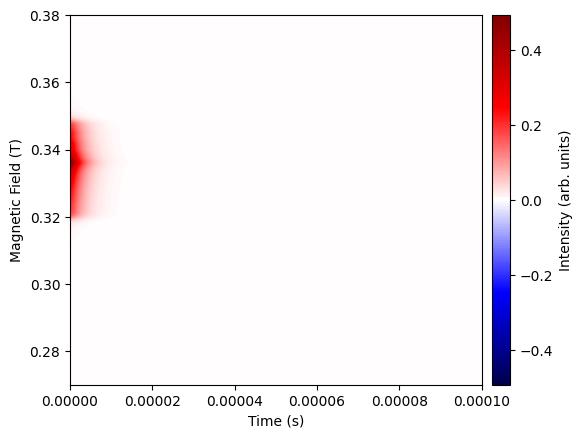

In [243]:
mars.visualization.time_resolved.plot_2d_timeresolved(fields, time_simulations, out)

In [251]:
creator = spectra_manager.DensityTimeSpectra(
    populator="propagator",
    hamiltonian_mode = "secular",
    context=context,
    freq=freq,
    harmonic=0,
    sample=sample_5,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_5, fields=fields, time=time_simulations)

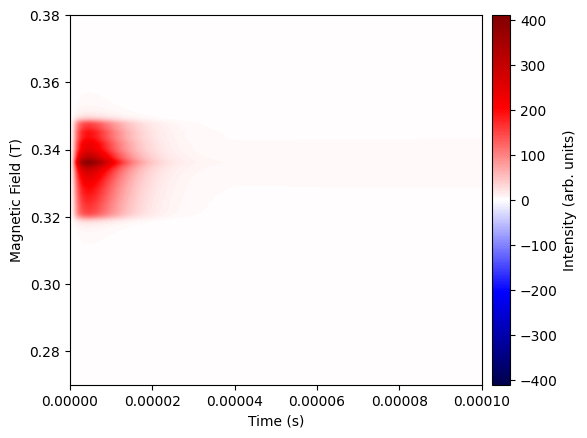

In [235]:
mars.visualization.time_resolved.plot_2d_timeresolved(fields, time_simulations, out)

### 5.1. Kinetic Creator

In [57]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)
time_calculation_results = []

path = f"example_5_kinetic_{device}_dtype_{dtype}.csv"
meta = {"dtype": str(dtype), "device": str(device), "sample_description": "spin S = 1 connected with other spin 1/2 in chain with J interaction and anisotropy"}

for num_electrons in range(1, 3):
    sample_function = functools.partial(create_relaxation_coupled, num_electrons=num_electrons)
    context_function = functools.partial(set_relaxation_and_initial_channels, num_contexts=3)
    
    result = time_spectrum_calculation_full_pipeline_timedep(
        sample_creation_func=sample_function,
        sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype,},
        freq=freq, field_range=field_range, time_range=time_range,
        n_points=n_field_points, n_points_time=time_points,
        context=context_function,
        temperature=temperature,
        computational_details=computational_details,
        n_warmup=2, n_iterations=5,
    )
    time_calculation_results.append({"num_electrons": num_electrons, "mean": result[0], "std": result[1]})
    save_csv(path, time_calculation_results, meta)

In [58]:
time_calculation_results

[{'num_electrons': 1, 'mean': 124.74612000005436, 'std': 1.1814317560147929},
 {'num_electrons': 2, 'mean': 347.2544199998083, 'std': 76.56466172840283}]

### 5.2. RWA

In [54]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)
time_calculation_results = []

path = f"example_5_RWA_{device}_dtype_{dtype}.csv"
meta = {"dtype": str(dtype), "device": str(device), "sample_description": "spin S = 1 connected with other spin 1/2 in chain with J interaction and anisotropy"}

for num_electrons in range(1, 3):
    sample_function = functools.partial(create_relaxation_coupled, num_electrons=num_electrons)
    context_function = functools.partial(set_relaxation_and_initial_channels, num_contexts=3)
    
    result = time_spectrum_calculation_full_pipeline_timedep(
        sample_creation_func=sample_function,
        creator_kwargs={"populator": "rwa"},
        sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype,},
        freq=freq, field_range=field_range, time_range=time_range,
        n_points=n_field_points, n_points_time=time_points,
        context=context_function,
        temperature=temperature,
        computational_details=computational_details,
        n_warmup=2, n_iterations=5,
        simulation_cls=spectra_manager.DensityTimeSpectra,
    )
    time_calculation_results.append({"num_electrons": num_electrons, "mean": result[0], "std": result[1]})
    save_csv(path, time_calculation_results, meta)

In [55]:
time_calculation_results

[{'num_electrons': 1, 'mean': 160.39653999978327, 'std': 7.443070945642955},
 {'num_electrons': 2, 'mean': 285.2770800003782, 'std': 10.853420906094982}]

### 5.3. PROPAGATOR

In [59]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)
time_calculation_results = []

path = f"example_5_propagator_{device}_dtype_{dtype}.csv"
meta = {"dtype": str(dtype), "device": str(device), "sample_description": "spin S = 1 connected with other spin 1/2 in chain with J interaction and anisotropy"}

for num_electrons in range(1, 3):
    sample_function = functools.partial(create_relaxation_coupled, num_electrons=num_electrons)
    context_function = functools.partial(set_relaxation_and_initial_channels, num_contexts=3)
    
    result = time_spectrum_calculation_full_pipeline_timedep(
        sample_creation_func=sample_function,
        creator_kwargs={"populator": "propagator", "hamiltonian_mode": "direct"},
        sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype,},
        freq=freq, field_range=field_range, time_range=time_range,
        n_points=n_field_points, n_points_time=time_points,
        context=context_function,
        temperature=temperature,
        computational_details=computational_details,
        n_warmup=2, n_iterations=5,
        simulation_cls=spectra_manager.DensityTimeSpectra,
    )
    
    time_calculation_results.append({"num_electrons": num_electrons, "mean": result[0], "std": result[1]})
    save_csv(path, time_calculation_results, meta)

In [60]:
time_calculation_results

[{'num_electrons': 1, 'mean': 1285.949160000746, 'std': 27.005526849722298},
 {'num_electrons': 2, 'mean': 37375.70826000083, 'std': 5821.112692298993}]

### 6. System of S=1 in batch computation

In [259]:
batch_size = 2
sample_6 = create_relaxation_batch_size(mesh=mesh, batch_size=batch_size, device=device, dtype=dtype)
context = set_relaxation_and_initial_channels_batches(sample_6, num_contexts=3)


field_range = (0.27, 0.38)
time_points = 100
time_range = (0.0, 1.0 * 1e-4)
time_simulations = torch.linspace(
            time_range[0],
            time_range[1],
            time_points,
            device=device,
            dtype=dtype
        ).expand(batch_size, -1)

fields = torch.linspace(
            field_range[0],
            field_range[1],
            n_field_points,
            device=device,
            dtype=dtype
        ).expand(batch_size, -1)

computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)

creator = spectra_manager.DensityTimeSpectra(
    context=context,
    output_mode = "total",
    populator = "propagator",
    freq=freq,
    harmonic=0,
    sample=sample_6,
    temperature=temperature,
    computational_details=computational_details,
    device=device,
    dtype=dtype
)

out = creator(sample=sample_6, fields=fields, time=time_simulations)

### 6.1. Kinetic Creator

In [ ]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)
time_calculation_results = []

path = f"example_6_kinetic_{device}_dtype_{dtype}.csv"
meta = {"dtype": str(dtype), "device": str(device), "sample_description": "spin S = 1 connected with other spin 1/2 in chain with J interaction and anisotropy"}

for batch_size in range(1, 3):
    sample_function = functools.partial(create_relaxation_batch_size, batch_size=batch_size)
    context_function = functools.partial(set_relaxation_and_initial_channels_batches, num_contexts=3)
    
    result = time_spectrum_calculation_full_pipeline_timedep(
        sample_creation_func=sample_function,
        sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype,},
        freq=freq, field_range=field_range, time_range=time_range,
        n_points=n_field_points, n_points_time=time_points,
        context=context_function,
        temperature=temperature,
        computational_details=computational_details,
        n_warmup=2, n_iterations=5,
    )
    time_calculation_results.append({"batch_size": batch_size, "mean": result[0] / batch_size, "std": result[1] / math.sqrt(batch_size)})
    save_csv(path, time_calculation_results, meta)

### 6.2. RWA

In [ ]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)
time_calculation_results = []

path = f"example_6_RWA_{device}_dtype_{dtype}.csv"
meta = {"dtype": str(dtype), "device": str(device), "sample_description": "spin S = 1 connected with other spin 1/2 in chain with J interaction and anisotropy"}

for batch_size in range(1, 3):
    sample_function = functools.partial(create_relaxation_batch_size, batch_size=batch_size)
    context_function = functools.partial(set_relaxation_and_initial_channels_batches, num_contexts=3)
    
    result = time_spectrum_calculation_full_pipeline_timedep(
        sample_creation_func=sample_function,
        creator_kwargs={"populator": "rwa"},
        sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype,},
        freq=freq, field_range=field_range, time_range=time_range,
        n_points=n_field_points, n_points_time=time_points,
        context=context_function,
        temperature=temperature,
        computational_details=computational_details,
        n_warmup=2, n_iterations=5,
        simulation_cls=spectra_manager.DensityTimeSpectra,
    )
    
    time_calculation_results.append({"batch_size": batch_size, "mean": result[0] / batch_size, "std": result[1] / math.sqrt(batch_size)})
    save_csv(path, time_calculation_results, meta)

### 6.3. PROPAGATOR

In [ ]:
computational_details = spectra_manager.ComputationalDetails(intensity_threshold=1e-4, res_field_r_tol=1e-4)
time_calculation_results = []

path = f"example_6_propagator_{device}_dtype_{dtype}.csv"
meta = {"dtype": str(dtype), "device": str(device), "sample_description": "spin S = 1 connected with other spin 1/2 in chain with J interaction and anisotropy"}

for batch_size in range(1, 3):
    sample_function = functools.partial(create_relaxation_batch_size, batch_size=batch_size)
    context_function = functools.partial(set_relaxation_and_initial_channels_batches, num_contexts=3)
    
    result = time_spectrum_calculation_full_pipeline_timedep(
        sample_creation_func=sample_function,
        creator_kwargs={"populator": "propagator", "hamiltonian_mode": "direct"},
        sample_kwargs = {"mesh": mesh, "device": device, "dtype": dtype,},
        freq=freq, field_range=field_range, time_range=time_range,
        n_points=n_field_points, n_points_time=time_points,
        context=context_function,
        temperature=temperature,
        computational_details=computational_details,
        n_warmup=2, n_iterations=5,
        simulation_cls=spectra_manager.DensityTimeSpectra,
    )
    
    time_calculation_results.append({"batch_size": batch_size, "mean": result[0] / batch_size, "std": result[1] / math.sqrt(batch_size)})
    save_csv(path, time_calculation_results, meta)